# A7 — Verificación y entrenamiento rápido (Notebook dedicada)

Este notebook A7 carga un modelo entrenado (`.h5`) y su `tokenizer` (`.pkl`) si existen, y opcionalmente reentrena un ejemplo pequeño (RE_TRAIN=True) para generar artefactos reproducibles.

In [ ]:
# Celda: loader - busca modelos y tokenizadores en lstm_notbook/artifacts o lstm_notebook
import os, pickle
from pathlib import Path
import numpy as np
ARTIFACT_DIR = Path('lstm_notebook') / 'artifacts'
ALT_DIR = Path('lstm_notebook')
candidates = [ARTIFACT_DIR / 'spam_lstm_model_refit.h5', ARTIFACT_DIR / 'spam_lstm_model_demo.h5', ALT_DIR / 'spam_lstm_model_refit.h5', ALT_DIR / 'spam_lstm_model_demo.h5']
tok_candidates = [ARTIFACT_DIR / 'tokenizer_refit.pkl', ARTIFACT_DIR / 'tokenizer_demo.pkl', ALT_DIR / 'tokenizer_refit.pkl', ALT_DIR / 'tokenizer_demo.pkl']
model = None
tokenizer = None
from tensorflow.keras.models import load_model
import tensorflow as tf
# custom objects mapping (maneja 'NotEqual' si aparece)
CUSTOM = {'NotEqual': tf.math.not_equal, 'Equal': tf.math.equal}
for p in candidates:
    try:
        if p.exists():
            with tf.keras.utils.custom_object_scope(CUSTOM):
                model = load_model(str(p))
            print('Modelo cargado desde', p)
            break
    except Exception as e:
        print('Intento de carga falló desde', p, ':', e)
# cargar tokenizador si existe
for t in tok_candidates:
    try:
        if t.exists():
            with open(t, 'rb') as f:
                tokenizer = pickle.load(f)
            print('Tokenizador cargado desde', t)
            break
    except Exception as e:
        print('No se pudo cargar tokenizador desde', t, ':', e)
# variables por defecto si no hay tokenizador
MAX_LEN = 20
VOCAB = 2000
print('Loader terminado. model is', 'present' if model is not None else 'None', ', tokenizer is', 'present' if tokenizer is not None else 'None')

Modelo cargado desde lstm_notebook\artifacts\spam_lstm_model_demo.h5
Tokenizador cargado desde lstm_notebook\artifacts\tokenizer_demo.pkl
Loader terminado. model is present , tokenizer is present


Ejecutando pipeline de entrenamiento (A7 demo)...
Epoch 1/5


c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5714 - loss: 0.6924 - val_accuracy: 0.3333 - val_loss: 0.6971
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5714 - loss: 0.6924 - val_accuracy: 0.3333 - val_loss: 0.6971
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5714 - loss: 0.6896 - val_accuracy: 0.3333 - val_loss: 0.7007
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5714 - loss: 0.6896 - val_accuracy: 0.3333 - val_loss: 0.7007
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5714 - loss: 0.6866 - val_accuracy: 0.3333 - val_loss: 0.7045
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.5714 - loss: 0.6866 - val_accuracy: 0.3333 - val_loss: 0.7045
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.5714 - loss: 0.6835 - val_accuracy: 0.3333 - val_loss: 0.7075
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.5714 - loss: 0.6835 - val_accuracy: 0.3333 - val_loss: 0.7075
Epoch 5/5
1/1 ━━

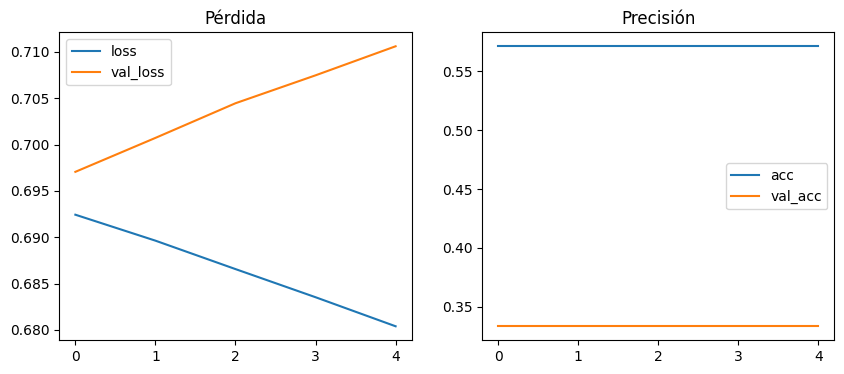

Entrenamiento A7 completado. Variables: model, tokenizer, X_test, y_test.


In [4]:
# Celda: Entrenamiento rápido (RE_TRAIN=True reentrena el ejemplo)
RE_TRAIN = True  # Cambia a False para usar modelo ya cargado
if (model is None) or RE_TRAIN:
    print('Ejecutando pipeline de entrenamiento (A7 demo)...')
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense
    from tensorflow.keras.optimizers import Adam
    import re
    # dataset pequeño de ejemplo
    texts = [
        'win money now',
        'limited offer buy today',
        'meeting at 10am',
        'project deadline extended',
        'click here to claim prize',
        'please review attached document',
        'your account has been suspended',
        'lunch meeting tomorrow',
        'free trial offer',
        'classroom schedule update'
    ]
    labels = [1,1,0,0,1,0,1,0,1,0]
    def clean_text(s):
        s = str(s).lower()
        s = re.sub(r'http\\\\S+|www\\\\.\\\\S+', ' ', s)
        s = re.sub(r'\\\\S+@\\\\S+', ' ', s)
        s = re.sub(r'[^a-z0-9\\\\s]', ' ', s)
        s = re.sub(r'\\\\s+', ' ', s).strip()
        return s
    texts = [clean_text(t) for t in texts]
    tokenizer = Tokenizer(num_words=VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(texts)
    seqs = tokenizer.texts_to_sequences(texts)
    X = pad_sequences(seqs, maxlen=MAX_LEN, padding='post')
    import numpy as np
    y = np.array(labels)
    # split
    from sklearn.model_selection import train_test_split
    strat = y if len(set(y))>1 else None
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=strat)
    # build model
    model = Sequential([
        Embedding(input_dim=VOCAB, output_dim=50, input_length=MAX_LEN),
        Bidirectional(LSTM(64)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=8, verbose=1)
    # mostrar gráficas
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend(); plt.title('Pérdida')
    plt.subplot(1,2,2)
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc' if 'val_acc' in history.history else None
    plt.plot(history.history.get(acc_key, []), label='acc')
    if val_acc_key: plt.plot(history.history.get(val_acc_key, []), label='val_acc')
    plt.legend(); plt.title('Precisión')
    plt.show()
    globals().update({'model': model, 'tokenizer': tokenizer, 'X_test': X_test, 'y_test': y_test})
    print('Entrenamiento A7 completado. Variables: model, tokenizer, X_test, y_test.')
else:
    print('Usando modelo cargado previamente. Si quieres reentrenar, establece RE_TRAIN=True y ejecuta esta celda.')

# Qué significan las gráficas de entrenamiento

A continuación se explica cómo interpretar las dos gráficas que genera la celda de entrenamiento:

- **Pérdida (loss vs val_loss):**
  - La curva `loss` muestra la pérdida en el conjunto de entrenamiento; `val_loss` muestra la pérdida en el conjunto de validación.
  - Una pérdida más baja indica que el modelo ajusta mejor los datos según la función de coste (a menudo `binary_crossentropy`).
  - Si `loss` baja mientras `val_loss` comienza a subir, es un signo de *sobreajuste* (overfitting): el modelo memoriza el entrenamiento y su rendimiento en datos nuevos empeora.
  - Si ambas curvas son altas y no descienden, el modelo está *subajustado* (underfitting) y necesita más capacidad o datos.

- **Precisión (accuracy vs val_accuracy):**
  - Muestra la fracción de predicciones correctas en entrenamiento y validación.
  - Esperamos que ambas curvas aumenten y se estabilicen; una gran brecha entre `accuracy` y `val_accuracy` también indica sobreajuste.

- **Qué buscar en estas gráficas (reglas prácticas):
  - Buen indicio: `loss` y `val_loss` decrecientes y convergentes; `accuracy` y `val_accuracy` crecientes y cercanas.
  - Sobreajuste: `loss` decrece, `val_loss` se estabiliza o sube; `accuracy` alta y `val_accuracy` significativamente menor.
  - Ruido en las curvas es normal con conjuntos pequeños — no saques conclusiones fuertes con pocos ejemplos.

- **Acciones recomendadas si ves problemas:**
  - Para sobreajuste: más datos, regularización (Dropout, L2), reducción de complejidad del modelo, early stopping.
  - Para subajuste: aumentar la capacidad (más unidades o capas), entrenar más épocas, mejorar la representación (embeddings preentrenados), ajustar la tasa de aprendizaje.

- **Nota sobre este notebook:**
  - Las gráficas aquí se generan con un conjunto de ejemplo muy pequeño (propósito demostrativo). Para conclusiones fiables usa un dataset representativo y mayor.


In [ ]:
# Celda: Evaluación (mide y muestra reporte)
from sklearn.metrics import classification_report, accuracy_score
if 'model' in globals() and 'X_test' in globals():
    preds = (model.predict(X_test) > 0.5).astype(int).flatten()
    print(classification_report(y_test, preds, target_names=['no deseado','spam']))
    print('Accuracy:', accuracy_score(y_test, preds))
else:
    print('No hay modelo o X_test disponibles. Ejecuta la celda de entrenamiento o carga primero.')

In [5]:
# Celda: Guardado robusto de artefactos
import os, pickle, shutil
from pathlib import Path
ARTIFACT_DIR = Path('lstm_notebook') / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
if 'model' not in globals():
    print('No hay modelo en memoria. Entrena o carga antes de guardar.')
else:
    # intentar guardar en .h5, si falla guardar pesos y arquitectura
    model_path = ARTIFACT_DIR / 'spam_lstm_model_demo.h5'
    try:
        model.save(str(model_path))
        print('Modelo guardado en', model_path)
    except Exception as e:
        print('Error guardando .h5:', e)
        weights_path = ARTIFACT_DIR / 'spam_lstm_model_demo.weights.h5'
        model.save_weights(str(weights_path))
        arch_path = ARTIFACT_DIR / 'spam_lstm_model_demo_arch.json'
        try:
            arch_path.write_text(model.to_json(), encoding='utf-8')
            print('Arquitectura guardada en', arch_path)
        except Exception as e2:
            print('No fue posible guardar arquitectura:', e2)
    # guardar tokenizer
    if 'tokenizer' in globals():
        tok_path = ARTIFACT_DIR / 'tokenizer_demo.pkl'
        with open(tok_path, 'wb') as f: pickle.dump(tokenizer, f)
        print('Tokenizador guardado en', tok_path)
    # generar reporte minimo
    try:
        preds = (model.predict(X_test) > 0.5).astype(int).flatten()
        from sklearn.metrics import classification_report, accuracy_score
        report_path = ARTIFACT_DIR / 'experiment_report.txt'
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write('Evaluation results:\\n')
            f.write(classification_report(y_test, preds, target_names=['no deseado','spam']))
            f.write('\\nAccuracy: %f\\n' % accuracy_score(y_test, preds))
        print('Reporte escrito en', report_path)
    except Exception as e:
        print('No fue posible generar el reporte:', e)

Modelo guardado en lstm_notebook\artifacts\spam_lstm_model_demo.h5
Tokenizador guardado en lstm_notebook\artifacts\tokenizer_demo.pkl
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
Reporte escrito en lstm_notebook\artifacts\experiment_report.txt
Reporte escrito en lstm_notebook\artifacts\experiment_report.txt


c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\Desktop\REDES-EJEMPLO-PIA-NNW\AGENTEia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

# Qué anexar con la entrega A7

Incluye los siguientes archivos en la carpeta de entrega o ZIP:
- `lstm_notebook/artifacts/spam_lstm_model_demo.h5` (modelo HDF5) o `spam_lstm_model_refit.h5`
- `lstm_notebook/artifacts/tokenizer_demo.pkl` o `tokenizer_refit.pkl`
- `lstm_notebook/artifacts/experiment_report.txt` (métricas y resumen)
- `lstm_notebook/a7_notebook.ipynb` (este notebook con instrucciones y comprobaciones)

Explicación breve recomendada: describir la arquitectura usada (Embedding -> Bidirectional LSTM -> Dense -> Sigmoid), rendimiento observado, impacto social/tecnológico/academico, y recomendaciones para mejorar (más datos, embeddings preentrenados, balanceo de clases, regularización).